Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['fake', 'real']
Total Images: 24000
Train: 16800, Val: 3600, Test: 3600
Using: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



 Epoch 1/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.5658 | Val Loss: 0.4194 | Accuracy: 82.25%

 Epoch 2/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.2979 | Val Loss: 0.3665 | Accuracy: 85.25%

 Epoch 3/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.2027 | Val Loss: 0.3350 | Accuracy: 88.56%

 Epoch 4/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.1492 | Val Loss: 0.2875 | Accuracy: 88.97%

 Epoch 5/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.1162 | Val Loss: 0.2858 | Accuracy: 89.33%

 Epoch 6/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.0908 | Val Loss: 0.3156 | Accuracy: 89.89%

 Epoch 7/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.0683 | Val Loss: 0.3607 | Accuracy: 89.92%

 Epoch 8/8
Batch 0/263
Batch 100/263
Batch 200/263
Train Loss: 0.0652 | Val Loss: 0.3597 | Accuracy: 89.28%

 FINAL TEST EVALUATION (UNSEEN DATA)
Final Test Accuracy: 89.08%


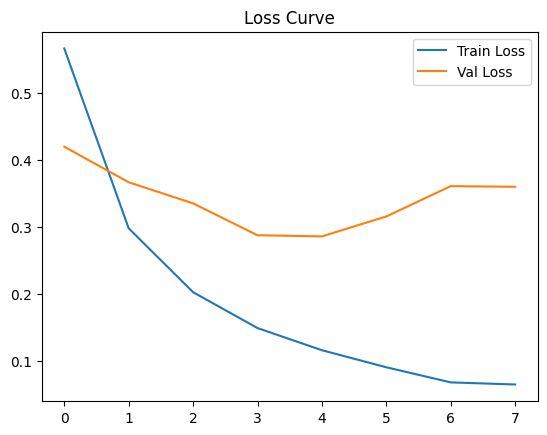

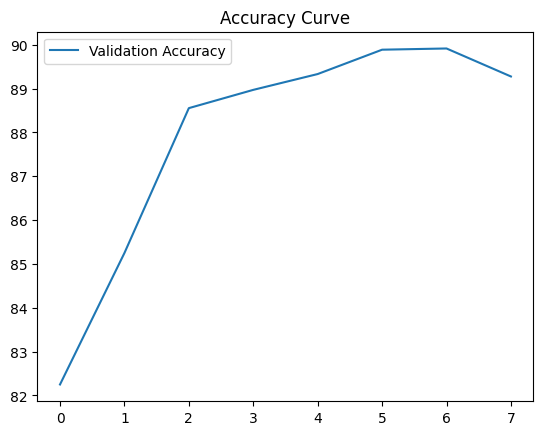


Confusion Matrix:
 [[1526  239]
 [ 154 1681]]

Classification Report:

              precision    recall  f1-score   support

        fake       0.91      0.86      0.89      1765
        real       0.88      0.92      0.90      1835

    accuracy                           0.89      3600
   macro avg       0.89      0.89      0.89      3600
weighted avg       0.89      0.89      0.89      3600



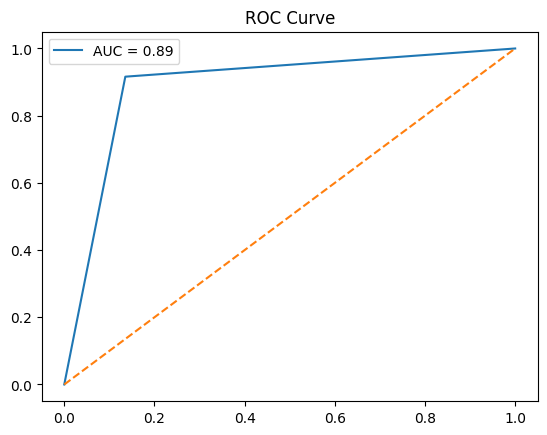

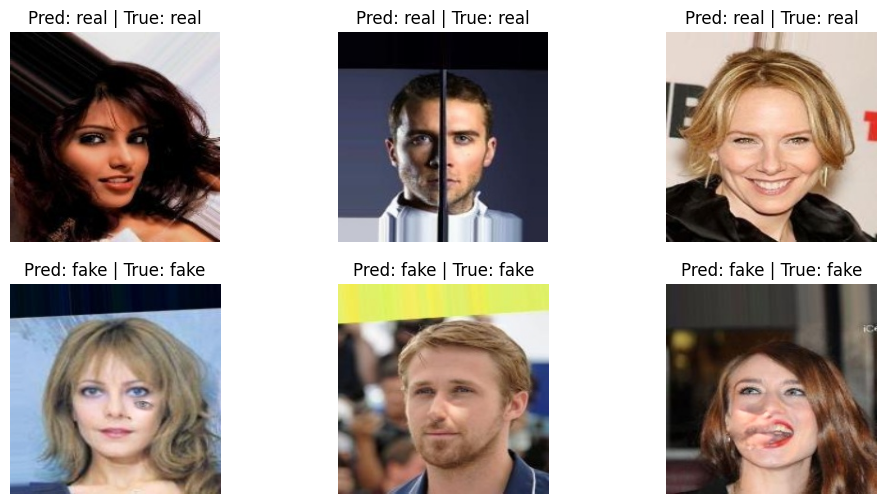

In [2]:
# ================== FINAL IMPROVED TRAINING PIPELINE ==================

!pip install -q scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import numpy as np
import random

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from google.colab import drive
drive.mount('/content/drive')

# -------- COPY DATA (FAST STORAGE) --------
!cp -r /content/drive/MyDrive/splicing_dataset_final_v3 /content/

data_path = "/content/splicing_dataset_final_v3"

# -------- TRANSFORMS --------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

# -------- LOAD DATA --------
dataset = datasets.ImageFolder(data_path, transform=transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

# ================== TRAIN / VAL / TEST SPLIT ==================
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# -------- LOADERS --------
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=64, num_workers=2)
test_loader = DataLoader(test_data, batch_size=64, num_workers=2)

# -------- DEVICE --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = models.resnet18(pretrained=True)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

epochs = 8

train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")

for epoch in range(epochs):
    print(f"\n Epoch {epoch+1}/{epochs}")

    # -------- TRAIN --------
    model.train()
    running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 100 == 0:
            print(f"Batch {i}/{len(train_loader)}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:,1]
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss /= len(val_loader)
    accuracy = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Accuracy: {accuracy:.2f}%")

    # EARLY STOPPING (prevents overfitting)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_resnet18.pth")

# ================== FINAL TEST EVALUATION ==================
print("\n FINAL TEST EVALUATION (UNSEEN DATA)")

model.load_state_dict(torch.load("/content/drive/MyDrive/best_resnet18.pth"))

model.eval()
correct = 0
total = 0

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Final Test Accuracy: {test_accuracy:.2f}%")

# ================== SAVE FINAL MODEL ==================
torch.save(model.state_dict(), "/content/drive/MyDrive/resnet18_splicing_final.pth")

# ================== VISUALIZATION ==================

# LOSS CURVE
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# ACCURACY
plt.figure()
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# CONFUSION MATRIX
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:\n", cm)

# CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(test_labels, test_preds, target_names=dataset.classes))

# ROC CURVE
fpr, tpr, _ = roc_curve(test_labels, test_preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# SAMPLE PREDICTIONS
plt.figure(figsize=(12,6))

for i in range(6):
    img, label = test_data[random.randint(0, len(test_data)-1)]
    input_img = img.unsqueeze(0).to(device)

    output = model(input_img)
    _, pred = torch.max(output, 1)

    plt.subplot(2,3,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Pred: {dataset.classes[pred]} | True: {dataset.classes[label]}")
    plt.axis('off')

plt.show()